(market_diffusion)=
```{raw} jupyter
<div id="qe-notebook-header" align="right" style="text-align:right;">
        <a href="https://quantecon.org/" title="quantecon.org">
                <img style="width:250px;display:inline;" width="250px" src="https://assets.quantecon.org/img/qe-menubar-logo.svg" alt="QuantEcon">
        </a>
</div>
```

# 双向学习下的市场扩散

```{index} single: Information; strategic experimentation
```

```{index} single: Learning; two-sided
```

```{contents} Contents
:depth: 2
```

## 概览

在 {doc}`pricing_information` 中，一个垄断者*拥有*信息并出售信息。

本讲研究这样一个市场：没有人出售信息，而每个人都在生产信息。

我们遵循 {cite:t}`BergemannValimaki1997` 的思路，他们研究了一个双头垄断市场，其中一家老牌企业与一家销售质量未知的新产品的企业进行价格竞争。

买家只能通过使用新产品才能了解其价值，而他们经验的总体记录是公开的。

因此，每一次新产品的购买同时也是一个消费决策和一次实验，其信息价值会外溢给所有人。

市场的双方都从同一个公开记录中学习，这正是这里"双向学习"的含义：买家和卖家在每个时点都持有相同的信念，从不出现信息不对称的情况。

本讲围绕三个结果展开。

第一，两家企业都*希望*获得更多信息，但只有新企业的销售能产生信息。

这种不对称性会削弱价格竞争：老牌企业的定价不如一次性博弈中那样激进，而进入者在早期能够获取更大的市场份额。

第二，当信念偏悲观时，均衡实验是**过度**的；当信念偏乐观时，均衡实验是**不足**的，中间存在唯一的交叉点。

第三，成功的新产品的扩散路径呈**S形**，这与一个悠久的经验传统相符，而拐点恰好出现在我们可以精确确定的某个信念处。

```{note}
与本节其余内容的联系是通过*信息的价值*建立的。

{doc}`blackwell_kihlstrom` 表明，当决策问题的价值函数在信念上是凸的时，决策者恰好会从更具信息性的实验中获益，因为更具信息性的实验会以凸序展开后验分布。

在这里，信念是一个鞅，而实验决定了信念展开的速度，因此每个企业从实验中获得的收益取决于其价值函数的凸性。

信念本身由一个对数似然比过程驱动，这与 {doc}`likelihood_ratio_process` 中研究的过程类似，只是现在运行在连续时间中。
```

让我们从导入相关模块开始。

In [1]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['figure.figsize'] = (10, 5)
np.set_printoptions(precision=4, suppress=True)

## 市场

买家在 $[0, 1]$ 上均匀分布，每人在每个瞬间需求一单位商品。

老牌产品为买家 $n$ 带来的价值为

$$
s_n = s + n h
$$ (eq:md_established)

新产品带来的价值为

$$
\mu_n = \mu + (1 - n) h .
$$ (eq:md_new)

参数 $h > 0$ 衡量水平差异化程度，因此接近 $n = 0$ 的买家天然更倾向于新产品，而接近 $n = 1$ 的买家则更倾向于老牌产品。

这是标准的霍特林结构，但有一个变化：新产品的纵向质量 $\mu$ 是**未知**的，可以取两个值之一，

$$
\mu \in \{\mu_L, \mu_H\},
\qquad
0 < s - h < \mu_L < s < \mu_H < s + h .
$$ (eq:md_condition4)

内部的不等式表明新产品可能比老牌产品更好或更差。

外部的不等式表明，在完全信息下，两家企业都会保留正的市场份额，因此这种创新不是颠覆性的。

两家企业的边际成本均为零。

如果新企业服务于 $[0, n]$ 范围内的买家，则每种产品所带来的平均流量价值为

$$
\bar\mu(n) = \mu + \frac{(2 - n)h}{2},
\qquad
\bar s(n) = s + \frac{(1 + n)h}{2} ,
$$ (eq:md_averages)

因此单位时间内的总剩余为 $n \bar\mu(n) + (1-n)\bar s(n)$。

将 $\mu(\alpha)$ 记为在信念 $\alpha = \Pr[\mu = \mu_H]$ 下的预期质量，经过一些代数运算，可将流量剩余写成方便的二次形式，

$$
F(n, \alpha) = s + \frac h2 + n\bigl(\mu(\alpha) - s + h\bigr) - n^2 h .
$$ (eq:md_flow)

In [2]:
class Market:
    """The duopoly of Bergemann and Valimaki (1997)."""

    def __init__(self, s=4.0, h=1.0, mu_L=3.1, mu_H=4.9, sigma=1.0):
        self.s, self.h = s, h
        self.mu_L, self.mu_H, self.sigma = mu_L, mu_H, sigma
        assert 0 < s - h < mu_L < s < mu_H < s + h, 'condition (4) fails'

    def mu(self, a):
        """Expected quality of the new product under belief a."""
        return (1 - a) * self.mu_L + a * self.mu_H

    def flow_surplus(self, n, a):
        return (self.s + self.h / 2 + n * (self.mu(a) - self.s + self.h)
                - n ** 2 * self.h)

## 双向学习

买家的个体经验是关于 $\mu$ 的一个带噪声的抽样，由于每个买家的测度为零，因此只有*总体*记录才重要。

当有一部分 $n$ 的买家使用新产品时，累积市场结果 $X$ 按以下方式演变：

$$
dX = n \mu \, dt + \sigma \sqrt{n} \, dB ,
$$ (eq:md_signal)

因此漂移项和方差都随实验规模 $n$ 成比例变化。

每个人都观察到 $X$，因此信念保持一致。

由于 $\mu$ 只能取两个值，信念 $\alpha_t = \Pr[\mu = \mu_H \mid \mathcal F_t]$
是一个充分统计量。

```{prf:proposition} 后验信念
:label: md_prop_belief

信念 $\alpha_t$ 是一个漂移为零的鞅，其瞬时方差为

$$
n \Sigma^2(\alpha) = n\left[\frac{\alpha(1-\alpha)(\mu_H - \mu_L)}{\sigma}\right]^2 .
$$ (eq:md_variance)
```

这是通过扩散过程观察到的两点先验的标准滤波结果；参见 {cite:t}`LiptserShiryaev1977`。

{eq}`eq:md_variance` 的两个特征驱动了一切。

方差**与 $n$ 呈线性关系**，因此信息的到达速率与实验规模成比例，而只有新企业的销售才能产生信息。

方差与 $\alpha^2(1-\alpha)^2$ 成比例，因此当信念最分散时学习速度最快，而当 $\alpha$ 接近 $0$ 或 $1$ 时学习就趋于停滞。

### 作为似然比过程的学习

值得探究一下 {eq}`eq:md_variance` 的来源，因为其机制正是 {doc}`likelihood_ratio_process` 中研究的机制，只是被移植到了连续时间中。

在长度为 $\Delta$ 的短时间间隔内，增量 $\Delta X$ 在任一假设下均服从均值为
$n \mu \Delta$、方差为 $\sigma^2 n \Delta$ 的正态分布，因此**对数似然比**的增量为

$$
\Delta \ell
= \log\frac{f_H(\Delta X)}{f_L(\Delta X)}
= \frac{(\mu_H - \mu_L)\,\Delta X - \tfrac12 n \Delta (\mu_H^2 - \mu_L^2)}{\sigma^2} .
$$ (eq:md_loglr)

信念随后遵循贝叶斯法则的对数比形式，与离散时间讲座中完全相同，

$$
\log\frac{\alpha_{t+\Delta}}{1 - \alpha_{t+\Delta}}
= \log\frac{\alpha_t}{1 - \alpha_t} + \Delta \ell .
$$ (eq:md_logodds)

我们直接实现 {eq}`eq:md_loglr` 和 {eq}`eq:md_logodds`，这在每一步都得到*精确*的贝叶斯更新，而不是对随机微分方程的离散化近似。

In [3]:
def simulate_beliefs(mkt, alpha0, T, dt, mu_true, rng, policy):
    """Simulate beliefs by exact Bayesian updating of the log odds.

    `mu_true` holds the true quality for each path, so the paths run in parallel.
    Returns an array of shape (number of paths, number of steps + 1).
    """
    mu_true = np.atleast_1d(np.asarray(mu_true, dtype=float))
    M, steps = len(mu_true), int(T / dt)
    a = np.empty((M, steps + 1))
    a[:, 0] = alpha0
    ell = np.full(M, np.log(alpha0 / (1 - alpha0)))
    dmu, half = mkt.mu_H - mkt.mu_L, (mkt.mu_H ** 2 - mkt.mu_L ** 2) / 2
    for k in range(steps):
        n = policy(a[:, k])
        dX = n * mu_true * dt + mkt.sigma * np.sqrt(n * dt) * rng.standard_normal(M)
        ell += (dmu * dX - n * dt * half) / mkt.sigma ** 2
        a[:, k + 1] = 1 / (1 + np.exp(-ell))
    return a

在使用它之前，我们通过蒙特卡洛方法检验 {prf:ref}`md_prop_belief`。

In [4]:
def Sigma2(mkt, a):
    return (a * (1 - a) * (mkt.mu_H - mkt.mu_L) / mkt.sigma) ** 2


mkt = Market()
rng = np.random.default_rng(0)
dt, n_draw = 1e-4, 400_000

print(f'{"alpha":>7s}{"simulated var/dt":>19s}{"formula n*Sigma^2":>20s}'
      f'{"mean/dt (s.e.)":>22s}')
for a0 in [0.2, 0.5, 0.8]:
    n = 0.5                                   # hold the experiment size fixed
    ell0 = np.log(a0 / (1 - a0))
    steps = []
    for mu_true, w in [(mkt.mu_H, a0), (mkt.mu_L, 1 - a0)]:
        k = int(n_draw * w)
        dX = n * mu_true * dt + mkt.sigma * np.sqrt(n * dt) * rng.standard_normal(k)
        ell = ell0 + ((mkt.mu_H - mkt.mu_L) * dX
                      - n * dt * (mkt.mu_H ** 2 - mkt.mu_L ** 2) / 2) / mkt.sigma ** 2
        steps.append(1 / (1 + np.exp(-ell)) - a0)
    d = np.concatenate(steps)
    se = d.std() / np.sqrt(len(d)) / dt
    print(f'{a0:7.2f}{d.var() / dt:19.6f}{n * Sigma2(mkt, a0):20.6f}'
          f'{d.mean() / dt:14.4f} ({se:.3f})')

  alpha   simulated var/dt   formula n*Sigma^2        mean/dt (s.e.)
   0.20           0.041586            0.041472        0.0034 (0.032)
   0.50           0.101145            0.101250        0.0606 (0.050)
   0.80           0.041428            0.041472        0.0096 (0.032)


模拟出的方差与 {eq}`eq:md_variance` 相符，而均值增量与零没有明显差异，这证实了信念构成一个鞅。

## 高效实验

一个选择 $n(\alpha)$ 的规划者会在当前剩余和销售所产生的信息之间进行权衡。

{cite:t}`BergemannValimaki1997` 通过在**无贴现**的极限情形下开展研究，避免了贴现会带来的非线性微分方程，他们使用了 {cite:t}`Dutta1991` 提出的强长期平均准则。

在这个极限下的最优策略是贴现策略在贴现率趋于零时的极限，因此跨期权衡依然存在。

贝尔曼方程变为

$$
\max_{n} \left\{ F(n, \alpha) - v(\alpha)
+ \tfrac12 n \Sigma^2(\alpha) V''(\alpha) \right\} = 0 ,
$$ (eq:md_bellman)

其中 $v(\alpha)$ 是完全信息下可达到的长期平均值，最后一项是**信息的价值**：即实验规模 $n$ 乘以学习速度 $\Sigma^2$ 再乘以影子价格 $V''$。

由于信念是一个鞅，因此不会出现一阶导数项。

由于 $\mu$ 最终会被了解，因此 $v$ 恰好是两个完全信息值的线性插值，

$$
v(\alpha) = \frac{s + \mu(\alpha) + \frac32 h}{2}
+ (1 - \alpha)\frac{(\mu_L - s)^2}{4h} + \alpha\frac{(\mu_H - s)^2}{4h} .
$$ (eq:md_vsocial)

巧妙之处在于，{eq}`eq:md_bellman` 中最大化括号内的值等于零，因此我们可以将其两边同除以 $n$ 而不改变最大化解。

这样做便将 $V''$ 完全从一阶条件中移除，只剩下

$$
\max_n \left\{ \frac{s + \frac h2 - v(\alpha)}{n} - h n \right\} + \text{terms free of } n ,
$$

其一阶条件以封闭形式给出了高效策略。

```{prf:proposition} 高效实验
:label: md_prop_efficient

新产品的高效市场份额为

$$
n^*(\alpha) = \sqrt{\frac{v(\alpha) - s - \frac h2}{h}} .
$$ (eq:md_nstar)
```

那位忽略销售的信息价值的短视规划者，会设定
$m^*(\alpha) = \arg\max_n F(n,\alpha)$。

In [5]:
def v_social(mkt, a):
    s, h = mkt.s, mkt.h
    return ((s + mkt.mu(a) + 1.5 * h) / 2
            + (1 - a) * (mkt.mu_L - s) ** 2 / (4 * h)
            + a * (mkt.mu_H - s) ** 2 / (4 * h))


def n_star(mkt, a):
    """Efficient share, equation (nstar)."""
    return np.sqrt((v_social(mkt, a) - mkt.s - mkt.h / 2) / mkt.h)


def m_star(mkt, a):
    """Myopically efficient share."""
    return (mkt.mu(a) - mkt.s + mkt.h) / (2 * mkt.h)

在 $\alpha \in \{0, 1\}$ 处已没有更多东西可以学习，因此这两者必须相符，事实也确实如此。

In [6]:
for a, mu_i in [(0.0, mkt.mu_L), (1.0, mkt.mu_H)]:
    direct = (mu_i - mkt.s + mkt.h) / (2 * mkt.h)
    print(f'alpha = {a}:  n* = {n_star(mkt, a):.6f}   '
          f'full-information share = {direct:.6f}')

A = np.linspace(1e-6, 1 - 1e-6, 4001)          # full grid, for plotting
A_int = np.linspace(0.05, 0.95, 1801)          # strictly interior grid

gap_myopic = n_star(mkt, A_int) - m_star(mkt, A_int)
print(f'\nn*(alpha) - m*(alpha) on [0.05, 0.95]:  '
      f'min {gap_myopic.min():.5f},  at alpha = 0.5 it is '
      f'{float(n_star(mkt, 0.5) - m_star(mkt, 0.5)):.5f}')

alpha = 0.0:  n* = 0.050000   full-information share = 0.050000
alpha = 1.0:  n* = 0.950000   full-information share = 0.950000

n*(alpha) - m*(alpha) on [0.05, 0.95]:  min 0.02101,  at alpha = 0.5 it is 0.17268


规划者总是比短视基准**多**进行实验，这体现了信息价值的跨期性，其表现形式为新产品销售量的额外增加。

## 均衡

现在让两家企业分别设定价格 $p_1$ 和 $p_2$，并让买家进行选择。

当 $s + nh - p_1 = \mu(\alpha) + (1-n)h - p_2$ 时，边际买家 $n$ 无差异，
这将市场份额锚定在价格上。

每家企业都求解一个动态规划问题，其中出现了各自的信息价值，同样的除以 $n$ 的技巧从一阶条件中消去了二阶导数。

```{prf:proposition} 均衡
:label: md_prop_equilibrium

存在唯一的马尔可夫完美均衡，其中

$$
p_1(\alpha) = \tfrac23\bigl(s - \mu(\alpha)\bigr) + \sqrt{2 h v_2(\alpha)},
\qquad
p_2(\alpha) = \tfrac13\bigl(\mu(\alpha) - s\bigr) + h ,
$$ (eq:md_prices)

新企业的市场份额为

$$
n(\alpha) = \sqrt{\frac{v_2(\alpha)}{2h}} ,
$$ (eq:md_share)

其中 $v_i(\alpha)$ 是企业 $i$ 在完全信息下的长期平均收入。
```

In [7]:
def v1(mkt, a):
    s, h = mkt.s, mkt.h
    return ((1 - a) * ((s - mkt.mu_L) / 3 + h) ** 2 / (2 * h)
            + a * ((s - mkt.mu_H) / 3 + h) ** 2 / (2 * h))


def v2(mkt, a):
    s, h = mkt.s, mkt.h
    return ((1 - a) * ((mkt.mu_L - s) / 3 + h) ** 2 / (2 * h)
            + a * ((mkt.mu_H - s) / 3 + h) ** 2 / (2 * h))


def n_eq(mkt, a):
    return np.sqrt(v2(mkt, a) / (2 * mkt.h))


def p1(mkt, a):
    return 2 / 3 * (mkt.s - mkt.mu(a)) + np.sqrt(2 * mkt.h * v2(mkt, a))


def p2(mkt, a):
    return (mkt.mu(a) - mkt.s) / 3 + mkt.h


def p1_myopic(mkt, a):
    return (mkt.s - mkt.mu(a)) / 3 + mkt.h


def n_myopic(mkt, a):
    return ((mkt.mu(a) - mkt.s) / 3 + mkt.h) / (2 * mkt.h)

将动态均衡与逐期博弈的静态均衡进行比较，揭示了本文核心的不对称性。

In [8]:
print('comparing the dynamic equilibrium with the static one, on [0.05, 0.95]')
print(f'  max |p2 - p2_myopic|   {np.abs(p2(mkt, A_int) - p2(mkt, A_int)).max():.2e}')
print(f'  min (p1 - p1_myopic)   {(p1(mkt, A_int) - p1_myopic(mkt, A_int)).min():.5f}')
print(f'  min (n_eq - n_myopic)  {(n_eq(mkt, A_int) - n_myopic(mkt, A_int)).min():.5f}')

comparing the dynamic equilibrium with the static one, on [0.05, 0.95]
  max |p2 - p2_myopic|   0.00e+00
  min (p1 - p1_myopic)   0.00671
  min (n_eq - n_myopic)  0.00336


新企业的价格*恰好*等于它的短视价格，这是线性偏好结构和无贴现假设的一个边缘性结果。

而老牌企业的定价则*高于*一次性博弈中的水平，从而让出了市场份额。

这正是那个令人瞠目的结果：老牌企业软化竞争，并不是因为力量薄弱，而是因为进入者的销售是信息的唯一来源，而老牌企业希望获得信息。

### 谁更看重信息？

贝尔曼方程表明，每家企业的信息价值等于其完全信息下的预期收入与当前收入之间的差距。

In [9]:
voi_1 = v1(mkt, A) - (1 - n_eq(mkt, A)) * p1(mkt, A)
voi_2 = v2(mkt, A) - n_eq(mkt, A) * p2(mkt, A)

print(f'established firm, minimum value of information  {voi_1.min():.3e}')
print(f'new firm, minimum value of information          {voi_2.min():.3e}')
print(f'ratio voi_1 / voi_2:  min {np.min(voi_1 / voi_2):.6f}, '
      f'max {np.max(voi_1 / voi_2):.6f}')

established firm, minimum value of information  1.800e-07
new firm, minimum value of information          9.000e-08
ratio voi_1 / voi_2:  min 2.000000, max 2.000000


两者都为正，因此两个价值函数都在信念上是凸的。

这正是 {doc}`blackwell_kihlstrom` 的逻辑在起作用：信念是一个鞅，更多的实验会使其进一步展开，而拥有凸值函数的企业会从这种展开中获益。

更令人意外的是，这个比值在任何信念下都恰好等于 $2$。

**老牌**企业对信息的重视程度是进入者的两倍，因为在均衡中，正是老牌企业相对于不确定性消解后本可获得的收入，放弃了当前的收入。

## 先过度实验，后不足实验

现在我们可以比较均衡份额与高效份额。

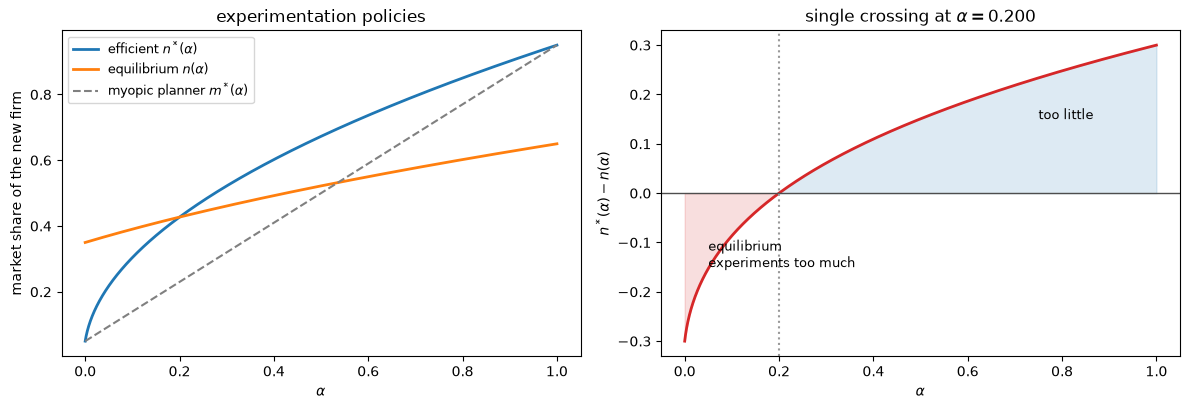

gap is monotone increasing: True
number of sign changes:     1


In [10]:
gap = n_star(mkt, A) - n_eq(mkt, A)
cross = A[np.argmin(np.abs(gap))]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].plot(A, n_star(mkt, A), lw=2, label=r'efficient $n^*(\alpha)$')
axes[0].plot(A, n_eq(mkt, A), lw=2, label=r'equilibrium $n(\alpha)$')
axes[0].plot(A, m_star(mkt, A), lw=1.5, ls='--', color='0.5',
             label=r'myopic planner $m^*(\alpha)$')
axes[0].set(xlabel=r'$\alpha$', ylabel='market share of the new firm',
            title='experimentation policies')
axes[0].legend(fontsize=9)

axes[1].plot(A, gap, lw=2, color='C3')
axes[1].axhline(0, color='0.3', lw=1)
axes[1].axvline(cross, color='0.6', ls=':', lw=1.5)
axes[1].fill_between(A, gap, 0, where=gap < 0, alpha=0.15, color='C3')
axes[1].fill_between(A, gap, 0, where=gap > 0, alpha=0.15, color='C0')
axes[1].annotate('equilibrium\nexperiments too much', (0.05, gap.min() / 2),
                 fontsize=9)
axes[1].annotate('too little', (0.75, gap.max() / 2), fontsize=9)
axes[1].set(xlabel=r'$\alpha$', ylabel=r'$n^*(\alpha) - n(\alpha)$',
            title=f'single crossing at ' + rf'$\alpha = {cross:.3f}$')
fig.tight_layout()
plt.show()

print(f'gap is monotone increasing: {np.all(np.diff(gap) > 0)}')
print(f'number of sign changes:     {int(np.sum(np.diff(np.sign(gap)) != 0))}')

这里的直觉在于谁必须降价来争取一个买家。

在悲观信念下，进入者规模较小，因此再吸引一个买家在存量收入上的成本很低，而老牌企业规模较大，不愿通过对所有人降价来保住自己的份额。

因此进入者会积极扩张，而市场则会出现过度实验。

在乐观信念下，情况正好相反，老牌企业会更努力地竞争，因而实验水平会低于高效水平。

## 随时间的扩散

到目前为止，一切都是状态 $\alpha$ 的函数。

要在日历时间上跟踪某个产品，我们需要知道当产品真的好时信念的运动规律。

在 $\mu = \mu_H$ 的条件下，信念会获得一个向上的漂移，因为数据是由 $\mu_H$ 产生的，而市场仍将 $1 - \alpha$ 的权重放在 $\mu_L$ 上，

$$
d\alpha = \frac{n(\alpha)(\mu_H - \mu_L)^2 \alpha (1-\alpha)^2}{\sigma^2}\, dt
+ \frac{(\mu_H - \mu_L)\alpha(1-\alpha)\sqrt{n(\alpha)}}{\sigma}\, dB .
$$ (eq:md_conditional)

去除噪声后，得到平均信念的确定性路径。

In [11]:
def mean_belief_path(mkt, alpha0, T, dt, policy):
    """Deterministic path of the mean posterior when mu = mu_H."""
    steps = int(T / dt)
    a = np.empty(steps + 1)
    a[0] = alpha0
    dmu2 = (mkt.mu_H - mkt.mu_L) ** 2 / mkt.sigma ** 2
    for k in range(steps):
        drift = policy(a[k]) * dmu2 * a[k] * (1 - a[k]) ** 2
        a[k + 1] = min(max(a[k] + drift * dt, 1e-12), 1 - 1e-12)
    return a

```{prf:proposition} S形扩散
:label: md_prop_sshape

在产品确实优质的条件下，平均市场份额 $\hat n(t)$ 随时间递增。

当 $\hat\alpha(t) \leq 1/3$ 时，其增长速率本身是递增的；此后则是递减的。
```

两种力量的结合产生了S形曲线。

随着信念远离零，学习会加速，从而加快进入者份额的增长；但均衡份额 $n(\alpha)$ 是凹的，因此信念的进一步改善所带来的份额增益会越来越小。

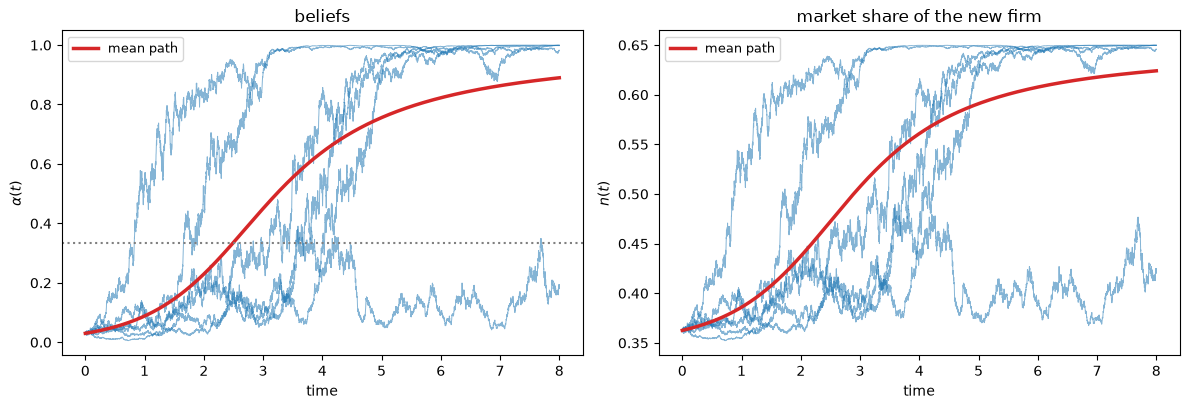

In [12]:
T, dt, alpha0 = 8.0, 1e-3, 0.03
policy = lambda a: n_eq(mkt, a)

a_mean = mean_belief_path(mkt, alpha0, T, dt, policy)
t_grid = np.linspace(0, T, len(a_mean))

rng = np.random.default_rng(12)
paths = simulate_beliefs(mkt, alpha0, T, dt, np.full(6, mkt.mu_H), rng, policy)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for pth in paths:
    axes[0].plot(t_grid, pth, lw=0.7, alpha=0.55, color='C0')
axes[0].plot(t_grid, a_mean, lw=2.5, color='C3', label='mean path')
axes[0].axhline(1 / 3, color='0.5', ls=':', lw=1.5)
axes[0].set(xlabel='time', ylabel=r'$\alpha(t)$', title='beliefs')
axes[0].legend(fontsize=9)

for pth in paths:
    axes[1].plot(t_grid, n_eq(mkt, pth), lw=0.7, alpha=0.55, color='C0')
axes[1].plot(t_grid, n_eq(mkt, a_mean), lw=2.5, color='C3', label='mean path')
axes[1].set(xlabel='time', ylabel=r'$n(t)$',
            title='market share of the new firm')
axes[1].legend(fontsize=9)
fig.tight_layout()
plt.show()

拐点恰好出现在 {prf:ref}`md_prop_sshape` 所说的位置。

In [13]:
n_mean = n_eq(mkt, a_mean)
growth = np.gradient(n_mean, t_grid)
k = np.argmax(growth)
print(f'share grows fastest at t = {t_grid[k]:.3f}, '
      f'where alpha = {a_mean[k]:.4f}   (theory: 1/3)')

drift = policy(A) * (mkt.mu_H - mkt.mu_L) ** 2 * A * (1 - A) ** 2
print(f'belief drift peaks at alpha = {A[np.argmax(drift)]:.4f}   '
      f'(theory: between 1/3 and 2/3)')

share grows fastest at t = 2.490, where alpha = 0.3334   (theory: 1/3)
belief drift peaks at alpha = 0.3830   (theory: between 1/3 and 2/3)


价格随份额同步变动。

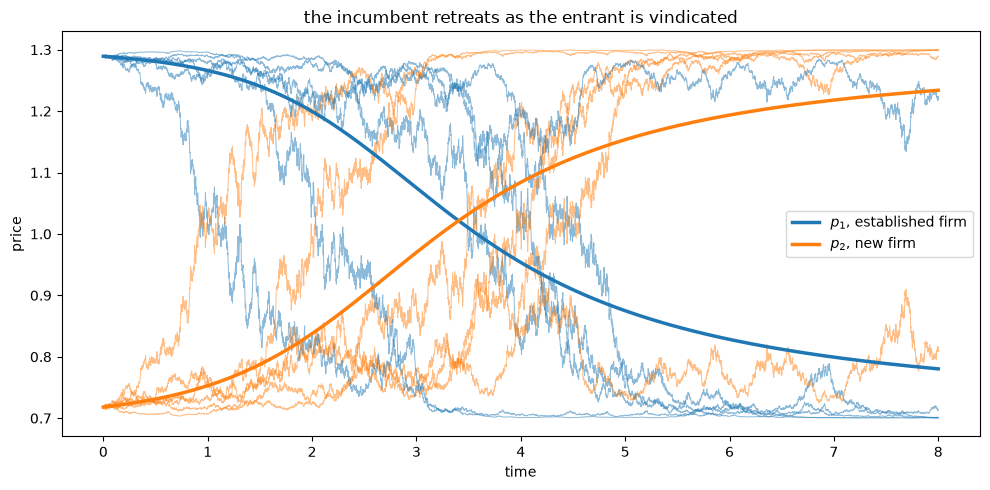

In [14]:
fig, ax = plt.subplots()
for pth in paths:
    ax.plot(t_grid, p1(mkt, pth), lw=0.7, alpha=0.5, color='C0')
    ax.plot(t_grid, p2(mkt, pth), lw=0.7, alpha=0.5, color='C1')
ax.plot(t_grid, p1(mkt, a_mean), lw=2.5, color='C0',
        label=r'$p_1$, established firm')
ax.plot(t_grid, p2(mkt, a_mean), lw=2.5, color='C1', label=r'$p_2$, new firm')
ax.set(xlabel='time', ylabel='price',
       title='the incumbent retreats as the entrant is vindicated')
ax.legend()
fig.tight_layout()
plt.show()

## 鞅性质

{cite:t}`BergemannValimaki1997` 从概率角度刻画了均衡的各个对象：进入者的价格是一个鞅，老牌企业的价格和进入者的份额是上鞅，两者的收入都是下鞅。

由于 $\alpha$ 是一个鞅，以上每一条性质都可以从 $\alpha$ 对应函数的形状中导出，我们可以通过模拟对这一切逐一进行检验。

In [15]:
rng = np.random.default_rng(3)
a0, M = 0.5, 20_000

# draw the true quality from the prior, one value per path
mu_true = np.where(rng.random(M) < a0, mkt.mu_H, mkt.mu_L)
ends = simulate_beliefs(mkt, a0, 4.0, 2e-3, mu_true, rng, policy)[:, -1]

rows = [
    ('belief', a0, ends.mean(), 'martingale'),
    ('share of new firm', n_eq(mkt, a0), n_eq(mkt, ends).mean(), 'supermartingale'),
    ('price of new firm', p2(mkt, a0), p2(mkt, ends).mean(), 'martingale'),
    ('price of incumbent', p1(mkt, a0), p1(mkt, ends).mean(), 'supermartingale'),
    ('revenue of incumbent', (1 - n_eq(mkt, a0)) * p1(mkt, a0),
     ((1 - n_eq(mkt, ends)) * p1(mkt, ends)).mean(), 'submartingale'),
    ('revenue of new firm', n_eq(mkt, a0) * p2(mkt, a0),
     (n_eq(mkt, ends) * p2(mkt, ends)).mean(), 'submartingale')]

print(f'{"":24s}{"t = 0":>10s}{"E[t = 4]":>11s}{"change":>10s}   prediction')
for name, x0, xT, pred in rows:
    print(f'{name:24s}{x0:10.4f}{xT:11.4f}{xT - x0:+10.4f}   {pred}')

                             t = 0   E[t = 4]    change   prediction
belief                      0.5000     0.5010   +0.0010   martingale
share of new firm           0.5220     0.5072   -0.0148   supermartingale
price of new firm           1.0000     1.0006   +0.0006   martingale
price of incumbent          1.0440     1.0132   -0.0308   supermartingale
revenue of incumbent        0.4990     0.5310   +0.0320   submartingale
revenue of new firm         0.5220     0.5389   +0.0168   submartingale


每一个符号都与预测相符。

进入者的预期份额随时间*下降*，尽管在产品真的优质的条件下其份额会上升，这是因为早期的积极扩张反映的是信息的价值，而不是对产品本身的信心。

两家企业都预期在未来赚得更多，这正是它们为了获取信息而牺牲当前利润的意义所在。

## 结语

本节现在有两讲的内容涉及价值完全是工具性的信息。

在 {doc}`pricing_information` 中，卖方设计并对实验定价，其中有趣的经济学源自布莱克韦尔序是不完全的这一事实。

在这里，没有人为信息定价，而有趣的经济学源自这样一个事实：只有一家企业的销售能够产生信息。

两者都建立在 {doc}`blackwell_kihlstrom` 提出的同一基础之上：对决策者而言，信息恰好在决策问题的价值函数在信念上是凸的这一程度上才具有价值。

{cite:t}`BergemannValimaki1997` 的独特之处在于，这种凸性是由*竞争对手*共同分享的。

由于两家企业都更愿意面对一个已经厘清了新产品质量的市场，关于纵向质量的不确定性缓和了价格竞争，这与 {cite:t}`ShakedSutton1982` 中确定性差异化所起的作用类似。

这正是为什么老牌企业一开始会以低价让进入者进入市场的原因，也是为什么一个成功的产品会沿着S形路径扩散的原因。

这里使用的连续时间技巧，特别是采取无贴现极限以使贝尔曼方程保持可处理性的手法，来自
{cite:t}`BoltonHarris1999`，他们是最早在连续时间中研究战略实验的学者。

一篇相关论文，{cite:t}`BergemannValimaki2000`，研究了同一个双头垄断问题，但假设存在无穷多个*完全相同*的消费者。

在那种同质性假设下，市场分割不复存在，因此本讲中产生扩散路径的水平差异化因素也不存在，分析转而集中于信息外部性如何影响市场效率。

## 练习

```{exercise-start}
:label: md_ex1
```

条件 {eq}`eq:md_condition4` 要求对两个质量水平都满足 $|\mu_i - s| < h$。

1. 通过代数推导证明，这一条件将新企业在完全信息下的均衡份额限制在区间 $(1/3, 2/3)$ 之内，因而对任意信念都有 $n(\alpha) \in (1/3, 2/3)$。

2. 用几组符合条件的 $(\mu_L, \mu_H)$ 数对进行数值验证。

3. {cite:t}`BergemannValimaki1997` 在绘制扩散图时使用了 $s = 4$、$h = 1$、
   $\mu_L = 2$、$\mu_H = 6$。

   检查这些参数是否满足 {eq}`eq:md_condition4`，计算 $\alpha \in \{0, 1\}$ 处的均衡份额，并计算每个质量水平下的短视高效份额 $m^*$。

   哪里出了问题？本讲的哪些结果仍然成立？

```{exercise-end}
```

```{solution-start} md_ex1
:class: dropdown
```

以下是一种解法：

在质量为 $\mu_i$ 的完全信息下，均衡份额为
$n_i = \bigl(\tfrac13(\mu_i - s) + h\bigr)/(2h)$。

条件 {eq}`eq:md_condition4` 给出 $-h < \mu_i - s < h$，因此
$\tfrac13(\mu_i - s) \in (-h/3, h/3)$，从而
$n_i \in \bigl(\tfrac{2h/3}{2h}, \tfrac{4h/3}{2h}\bigr) = (1/3, 2/3)$。

由于 $n(\alpha)^2$ 是 $n_0^2$ 和 $n_1^2$ 的凸组合，均衡份额对任意 $\alpha$ 都介于 $n_0$ 和 $n_1$ 之间。

In [16]:
for mu_L, mu_H in [(3.1, 4.9), (3.4, 4.6), (3.9, 4.1)]:
    m_ = Market(mu_L=mu_L, mu_H=mu_H)
    lo, hi = n_eq(m_, 0.0), n_eq(m_, 1.0)
    print(f'(mu_L, mu_H) = ({mu_L}, {mu_H}):  n_eq ranges over '
          f'[{lo:.4f}, {hi:.4f}]   inside (1/3, 2/3): {1/3 < lo and hi < 2/3}')

(mu_L, mu_H) = (3.1, 4.9):  n_eq ranges over [0.3500, 0.6500]   inside (1/3, 2/3): True
(mu_L, mu_H) = (3.4, 4.6):  n_eq ranges over [0.4000, 0.6000]   inside (1/3, 2/3): True
(mu_L, mu_H) = (3.9, 4.1):  n_eq ranges over [0.4833, 0.5167]   inside (1/3, 2/3): True


In [17]:
class LooseMarket(Market):
    def __init__(self, **kw):                 # skip the assertion
        self.s, self.h = kw['s'], kw['h']
        self.mu_L, self.mu_H, self.sigma = kw['mu_L'], kw['mu_H'], kw.get('sigma', 1.0)


paper = LooseMarket(s=4, h=1, mu_L=2, mu_H=6)
print(f'condition (4) needs  s - h < mu_L:  {paper.s - paper.h} < {paper.mu_L}?  '
      f'{paper.s - paper.h < paper.mu_L}')
print(f'condition (4) needs  mu_H < s + h:  {paper.mu_H} < {paper.s + paper.h}?  '
      f'{paper.mu_H < paper.s + paper.h}')
print(f'\nequilibrium shares:   n(0) = {n_eq(paper, 0.0):.4f}, '
      f'n(1) = {n_eq(paper, 1.0):.4f}')
for mu_i, nm in [(paper.mu_L, 'mu_L'), (paper.mu_H, 'mu_H')]:
    print(f'myopically efficient share at {nm}: '
          f'{(mu_i - paper.s + paper.h) / (2 * paper.h):+.4f}')

condition (4) needs  s - h < mu_L:  3 < 2?  False
condition (4) needs  mu_H < s + h:  6 < 5?  False

equilibrium shares:   n(0) = 0.1667, n(1) = 0.8333
myopically efficient share at mu_L: -0.5000
myopically efficient share at mu_H: +1.5000


论文图中使用的参数在两端都违反了 {eq}`eq:md_condition4`。

其后果是：*高效*配置落在了角点上：当 $\mu = \mu_L$ 时应将每个买家都分配给老牌产品，当 $\mu = \mu_H$ 时应将每个买家都分配给新产品，因此内点公式 {eq}`eq:md_nstar` 不再适用，{prf:ref}`md_prop_efficient` 中的效率比较也不再成立。

关于*均衡*的一切都依然成立，因为均衡份额仍严格保持在内点，分别为 $1/6$ 和 $5/6$。

这正是为什么这些参数适合用来绘制扩散路径——这也是该论文使用它们的唯一目的——以及为什么它们能画出比任何符合条件的参数组更为夸张的S形曲线。

```{solution-end}
```

```{exercise-start}
:label: md_ex2
```

本讲找到了一个使均衡实验从过度切换为不足的单一信念点。

1. 编写一个通过二分法定位该交叉点的函数。

2. 在保持中点 $\tfrac12(\mu_L + \mu_H) = s$ 不变的情况下，计算该交叉点随质量差 $\mu_H - \mu_L$ 扩大而变化的情况；然后再计算它随水平差异化参数 $h$ 变化的情况。

3. 只要比值
   $(\mu_H - \mu_L)/h$ 相同，两组实验都会得到相同的结果。

   猜测该交叉点的封闭形式，并进行数值检验。

4. 当质量中点偏离 $s$ 时，你的公式是否依然成立？

```{exercise-end}
```

```{solution-start} md_ex2
:class: dropdown
```

以下是一种解法：

In [18]:
def crossing(mkt, tol=1e-13):
    """Belief at which n*(alpha) = n(alpha), by bisection."""
    lo, hi = 1e-12, 1 - 1e-12
    f = lambda a: n_star(mkt, a) - n_eq(mkt, a)
    if f(lo) > 0 or f(hi) < 0:
        return np.nan
    while hi - lo > tol:
        mid = (lo + hi) / 2
        lo, hi = (mid, hi) if f(mid) < 0 else (lo, mid)
    return (lo + hi) / 2


print('widening the quality spread, midpoint fixed at s = 4, h = 1')
for spread in [0.4, 0.8, 1.2, 1.6, 1.9]:
    m_ = Market(s=4, h=1, mu_L=4 - spread / 2, mu_H=4 + spread / 2)
    print(f'   (mu_H - mu_L)/h = {spread / 1:.3f}:  crossing = {crossing(m_):.6f}')

print('\nvarying horizontal differentiation, mu = (3.4, 4.6)')
for h_ in [0.65, 0.8, 1.0, 1.5, 2.5]:
    m_ = Market(s=4, h=h_, mu_L=3.4, mu_H=4.6)
    print(f'   (mu_H - mu_L)/h = {1.2 / h_:.3f}:  crossing = {crossing(m_):.6f}')

widening the quality spread, midpoint fixed at s = 4, h = 1
   (mu_H - mu_L)/h = 0.400:  crossing = 0.433333
   (mu_H - mu_L)/h = 0.800:  crossing = 0.366667
   (mu_H - mu_L)/h = 1.200:  crossing = 0.300000
   (mu_H - mu_L)/h = 1.600:  crossing = 0.233333
   (mu_H - mu_L)/h = 1.900:  crossing = 0.183333

varying horizontal differentiation, mu = (3.4, 4.6)
   (mu_H - mu_L)/h = 1.846:  crossing = 0.192308
   (mu_H - mu_L)/h = 1.500:  crossing = 0.250000
   (mu_H - mu_L)/h = 1.200:  crossing = 0.300000
   (mu_H - mu_L)/h = 0.800:  crossing = 0.366667
   (mu_H - mu_L)/h = 0.480:  crossing = 0.420000


按比值 $(\mu_H - \mu_L)/h$ 排序，这两个表格是一致的，这表明该交叉点只通过这一比值取决于参数。

这些数字落在一条经过 $1/2$、斜率为 $-1/6$ 的直线上。

In [19]:
print(f'{"(mu_H-mu_L)/h":>15s}{"bisection":>12s}{"1/2 - ratio/6":>16s}{"error":>12s}')
for mu_L_, mu_H_, h_ in [(3.4, 4.6, 1.0), (3.1, 4.9, 1.0), (3.8, 4.2, 1.0),
                         (3.4, 4.6, 1.5), (3.4, 4.6, 0.8), (3.05, 4.95, 1.0)]:
    m_ = Market(s=4, h=h_, mu_L=mu_L_, mu_H=mu_H_)
    r = (mu_H_ - mu_L_) / h_
    c, pred = crossing(m_), 0.5 - r / 6
    print(f'{r:15.4f}{c:12.6f}{pred:16.6f}{c - pred:12.1e}')

  (mu_H-mu_L)/h   bisection   1/2 - ratio/6       error
         1.2000    0.300000        0.300000    -1.5e-14
         1.8000    0.200000        0.200000    -8.2e-15
         0.4000    0.433333        0.433333    -4.9e-15
         0.8000    0.366667        0.366667     1.9e-14
         1.5000    0.250000        0.250000     1.7e-14
         1.9000    0.183333        0.183333    -1.6e-14


所以当两个质量水平相对于 $s$ 对称分布时，切换点出现在

$$
\alpha^{\mathrm{cross}} = \frac12 - \frac{\mu_H - \mu_L}{6h} ,
$$

而条件 {eq}`eq:md_condition4` 使其严格落在 $(1/6, 1/2)$ 之内，因为该条件要求
$\mu_H - \mu_L < 2h$。

因此，随着质量差相对于 $h$ 扩大，过度实验的区域会*缩小*。

质量差扩大意味着学习的赌注更高，因而高效策略会以大量实验作出响应；而由每家企业私人收益动机驱动的均衡，除了在最悲观的信念下，都无法跟上这一步伐。

提高 $h$ 则会产生相反的效果，因为强烈依附于自身偏好的买家会削弱价格这一竞争工具的作用，从而使进入者比规划者所选择的更为自由地扩张。

这种对称性是关键所在。

In [20]:
print('moving the quality midpoint away from s, with mu = (3.4, 4.6), h = 1')
for s_ in [3.9, 4.0, 4.1]:
    m_ = Market(s=s_, h=1, mu_L=3.4, mu_H=4.6)
    mid = (3.4 + 4.6) / 2
    print(f'   s = {s_}  (midpoint {mid}):  crossing = {crossing(m_):.6f}'
          f'   formula = {0.5 - 1.2 / 6:.6f}')

moving the quality midpoint away from s, with mu = (3.4, 4.6), h = 1
   s = 3.9  (midpoint 4.0):  crossing = 0.245098   formula = 0.300000
   s = 4.0  (midpoint 4.0):  crossing = 0.300000   formula = 0.300000
   s = 4.1  (midpoint 4.0):  crossing = 0.358974   formula = 0.300000


一旦中点不再等于 $s$，这个公式就会失效，因此它是一个边缘性的结果，而非一般性结论。

```{solution-end}
```

```{exercise-start}
:label: md_ex3
```

本练习将与 {doc}`blackwell_kihlstrom` 的联系精确化。

在那一讲中，决策者恰好在决策问题的价值函数在信念上是凸的时才能从更具信息性的实验中获益，因为更具信息性的实验会产生后验分布的均值保持展开。

在这里，信念是一个鞅，而实验决定了它展开的速度，因此同样的逻辑适用于每一家企业。

1. 绘制每家企业的信息价值（即 $v_i(\alpha)$ 减去当前均衡收入）对 $\alpha$ 的曲线图。

2. 确认这两条曲线在内点处都为正，并在
   $\alpha \in \{0, 1\}$ 处趋于零，解释为何它们必须在那里趋于零。

3. 信息价值也等于 $\tfrac12 n(\alpha)\Sigma^2(\alpha)V_i''(\alpha)$。

   利用这一点求出 $V_i''(\alpha)$，并确认两个价值函数都是凸函数。

```{exercise-end}
```

```{solution-start} md_ex3
:class: dropdown
```

以下是一种解法：

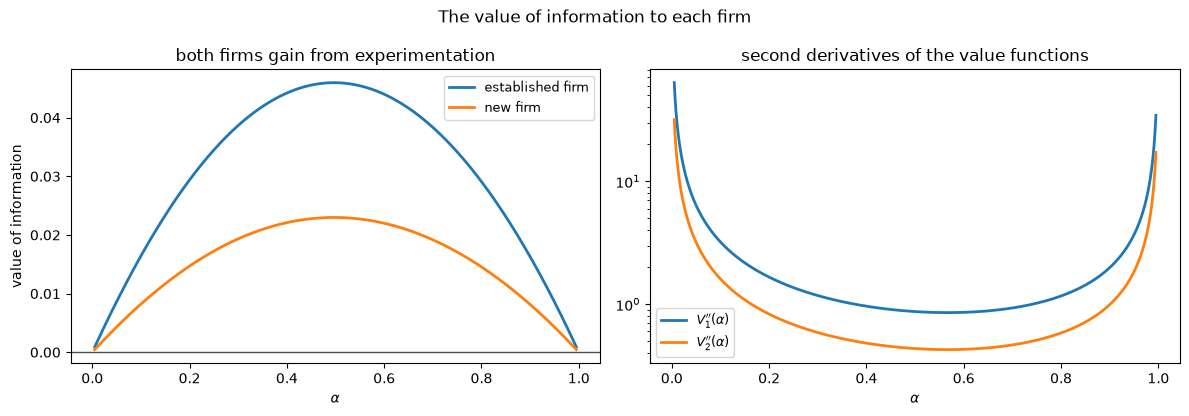

minimum value of information, established firm  8.957e-04
minimum value of information, new firm          4.479e-04
minimum of V1''  0.8531    minimum of V2''  0.4265


In [21]:
Ai = np.linspace(0.005, 0.995, 2001)
voi_1 = v1(mkt, Ai) - (1 - n_eq(mkt, Ai)) * p1(mkt, Ai)
voi_2 = v2(mkt, Ai) - n_eq(mkt, Ai) * p2(mkt, Ai)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].plot(Ai, voi_1, lw=2, label='established firm')
axes[0].plot(Ai, voi_2, lw=2, label='new firm')
axes[0].axhline(0, color='0.3', lw=1)
axes[0].set(xlabel=r'$\alpha$', ylabel='value of information',
            title='both firms gain from experimentation')
axes[0].legend(fontsize=9)

V1pp = 2 * voi_1 / (n_eq(mkt, Ai) * Sigma2(mkt, Ai))
V2pp = 2 * voi_2 / (n_eq(mkt, Ai) * Sigma2(mkt, Ai))
axes[1].plot(Ai, V1pp, lw=2, label=r"$V_1''(\alpha)$")
axes[1].plot(Ai, V2pp, lw=2, label=r"$V_2''(\alpha)$")
axes[1].set(xlabel=r'$\alpha$', yscale='log',
            title='second derivatives of the value functions')
axes[1].legend(fontsize=9)
fig.suptitle('The value of information to each firm')
fig.tight_layout()
plt.show()

print(f'minimum value of information, established firm  {voi_1.min():.3e}')
print(f'minimum value of information, new firm          {voi_2.min():.3e}')
print(f'minimum of V1\'\'  {V1pp.min():.4f}    minimum of V2\'\'  {V2pp.min():.4f}')

两条曲线在内点处都严格为正，两个二阶导数也都严格为正，因此两个价值函数都是凸函数。

信息价值在 $\alpha \in \{0, 1\}$ 处趋于零，有两个相互强化的原因。

在那里已没有更多东西可以学习，因此均衡与完全信息下的均衡相符，收入差距也就随之消失。

而且学习速度 $\Sigma^2(\alpha) \propto \alpha^2(1-\alpha)^2$ 同样趋于零，因此即便价值函数是凸的，一个不再揭示任何信息的实验也不会带来任何收益。

而两个二阶导数在端点处却*并不*趋于零，这恰恰是
{doc}`blackwell_kihlstrom` 所强调的要点：为信息付费的*意愿*一直保持为正，但当信念趋于退化时，信息的*供给*却枯竭了。

```{solution-end}
```